In [3]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import re
import ast

In [4]:
# Step 2: Load dataset
df = pd.read_csv("recipes.csv")  # change file name if needed
df.head()


,Unnamed: 0,recipe_name,prep_time,cook_time,total_time,servings,yield,ingredients,directions,rating,url,cuisine_path,nutrition,timing,img_src
0,0,Apple-Cranberry Crostada,NaN,NaN,NaN,8,6 to 8 - servings,"3 tablespoons butter, 2 pounds Granny Smith ap...",Heat butter in a large skillet over medium-hig...,4.4,https://www.allrecipes.com/recipe/76931/apple-...,/Desserts/Fruit Desserts/Apple Dessert Recipes/,"Total Fat 18g 23%, Saturated Fat 7g 34%, Chole...","Servings: 8, Yield: 6 to 8 - servings",https://www.allrecipes.com/thmb/Tf1wH73bfH6Oql...
1,1,Apple Pie by Grandma Ople,30 mins,1 hrs,1 hrs 30 mins,8,1 9-inch pie,"8 small Granny Smith apples, or as needed, ½ c...","Peel and core apples, then thinly slice. Set a...",4.8,https://www.allrecipes.com/recipe/12682/apple-...,/Desserts/Pies/Apple Pie Recipes/,"Total Fat 19g 24%, Saturated Fat 9g 46%, Chole...","Prep Time: 30 mins, Cook Time: 1 hrs, Total Ti...",https://www.allrecipes.com/thmb/1I95oiTGz6aEpu...
2,2,Sarah's Homemade Applesauce,10 mins,15 mins,25 mins,4,NaN,"4 apples - peeled, cored and chopped, ¾ cup w...","Combine apples, water, sugar, and cinnamon in ...",4.8,https://www.allrecipes.com/recipe/51301/sarahs...,/Side Dish/Applesauce Recipes/,"Total Fat 0g 0%, Sodium 3mg 0%, Total Carbohyd...","Prep Time: 10 mins, Cook Time: 15 mins, Total ...",https://www.allrecipes.com/thmb/VY5d0tZHB8xz6y...
3,3,Apple Crisp,30 mins,45 mins,1 hrs 15 mins,12,1 9x13-inch pan,"10 cups all-purpose apples, peeled, cored and ...",Preheat the oven to 350 degrees F (175 degrees...,4.7,https://www.allrecipes.com/recipe/12409/apple-...,/Desserts/Crisps and Crumbles Recipes/Apple Cr...,"Total Fat 8g 11%, Saturated Fat 5g 25%, Choles...","Prep Time: 30 mins, Cook Time: 45 mins, Total ...",https://www.allrecipes.com/thmb/uAzhPOh86PfR-N...
4,4,Apple Pie Filling,20 mins,20 mins,2 hrs 40 mins,40,5 9-inch pies,"18 cups thinly sliced apples, 3 tablespoons le...",Toss apples with lemon juice in a large bowl a...,4.7,https://www.allrecipes.com/recipe/12681/apple-...,/Desserts/Pies/Apple Pie Recipes/,"Total Fat 0g 0%, Sodium 61mg 3%, Total Carbohy...","Prep Time: 20 mins, Cook Time: 20 mins, Additi...",https://www.allrecipes.com/thmb/c0bbYaS1V_mTt_...


In [5]:
# Step 3: Check missing values
df.isnull().sum()

# Drop rows with too many missing values or fill where appropriate
df = df.dropna(subset=['recipe_name', 'ingredients'])
df['rating'] = df['rating'].fillna(df['rating'].mean())  # fill missing ratings
df['cuisine_path'] = df['cuisine_path'].fillna('Unknown')


In [6]:
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = str(text).encode('utf-8', 'ignore').decode('utf-8')  # remove weird chars
    text = re.sub(r'Â', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

text_cols = ['recipe_name', 'ingredients', 'directions', 'nutrition', 'cuisine_path']
for col in text_cols:
    df[col] = df[col].apply(clean_text)


In [7]:
def process_ingredients(ingredients):
    if pd.isnull(ingredients):
        return []
    ingredients = ingredients.lower()
    ingredients = re.sub(r'\([^)]*\)', '', ingredients)  # remove bracketed text
    ingredients = re.split(r',|;|\n', ingredients)
    ingredients = [re.sub(r'[^a-zA-Z\s]', '', i).strip() for i in ingredients]
    ingredients = [i for i in ingredients if len(i) > 1]
    return ingredients

df['cleaned_ingredients'] = df['ingredients'].apply(process_ingredients)



In [10]:
df['ingredients_joined'] = df['cleaned_ingredients'].apply(lambda x: ' '.join(x))


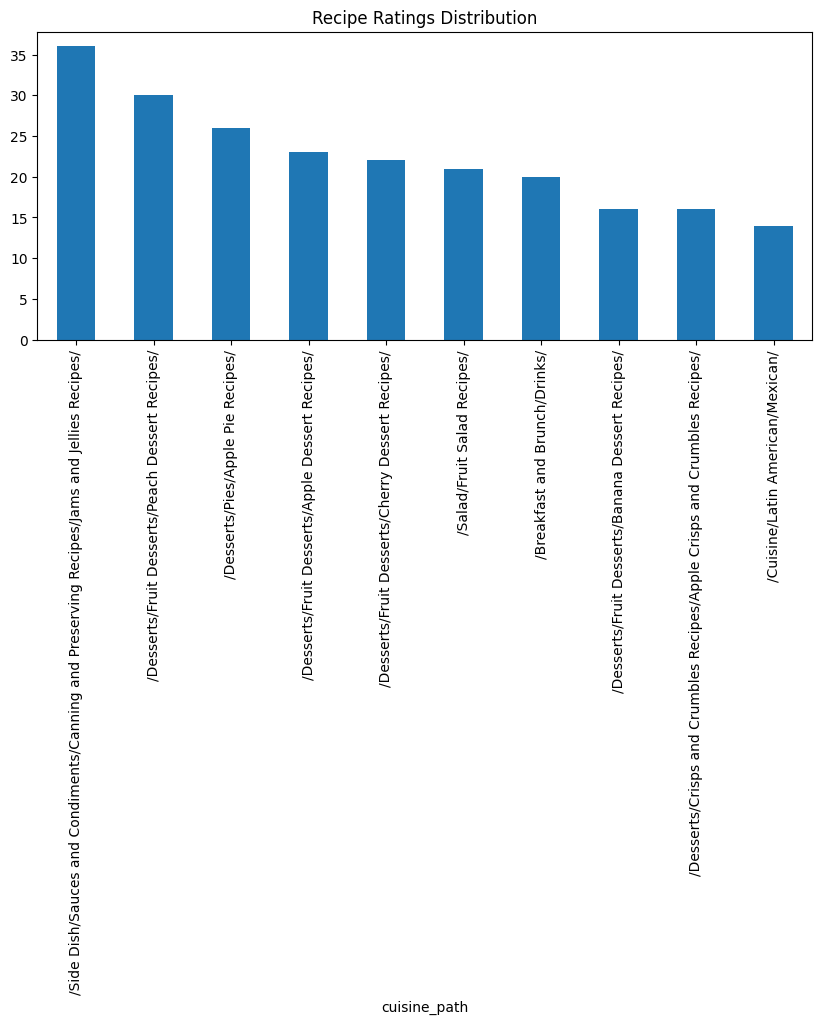

In [12]:
# How many cuisines
df['cuisine_path'].value_counts().head(10).plot(kind='bar', figsize=(10,4), title='Top Cuisines')

# Distribution of ratings
plt.title("Recipe Ratings Distribution")
plt.show()



In [13]:
df.to_csv("recipes_cleaned.csv", index=False)
print("✅ Preprocessing complete! Cleaned data saved as recipes_cleaned.csv")


✅ Preprocessing complete! Cleaned data saved as recipes_cleaned.csv
